In [ ]:
# SCENARIO 1 – LINEAR REGRESSION
# Ocean Temperature Prediction

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load Dataset
df = pd.read_csv("bottle.csv")   # Make sure file is in same folder

C:\Users\User\AppData\Local\Temp\ipykernel_26912\1791118069.py:2: DtypeWarning: Columns (0: IncTim, 1: DIC Quality Comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bottle.csv")   # Make sure file is in same folder


In [ ]:
print("Saravanan 24BAD105")

Saravanan 24BAD105


In [ ]:
# Select Features and Target
all_possible_features = ['Depthm', 'Salnty', 'O2ml_L', 'Lat_Dec', 'Lon_Dec']
features = [col for col in all_possible_features if col in df.columns]
target = 'T_degC'

data = df[features + [target] if all(f in df.columns for f in features) else [col for col in features if col in df.columns] + [target]]

In [ ]:
# Handle Missing Values (Mean Imputation)
data = data.fillna(data.mean())

In [ ]:
# Separate X and y
X = data[features]
y = data[target]

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Make Predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MSE: 6.221446882618065
RMSE: 2.494282839338407
R2 Score: 0.6492792001567061


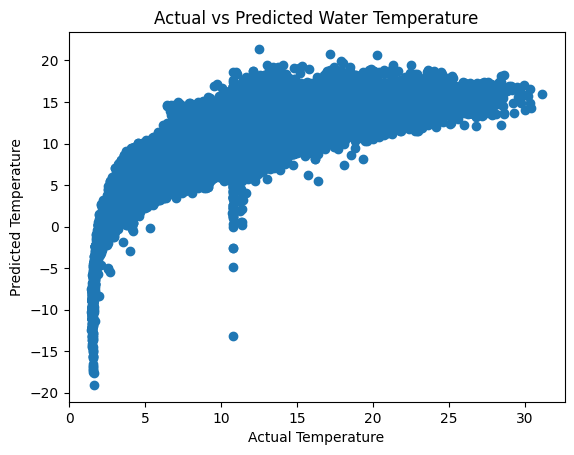

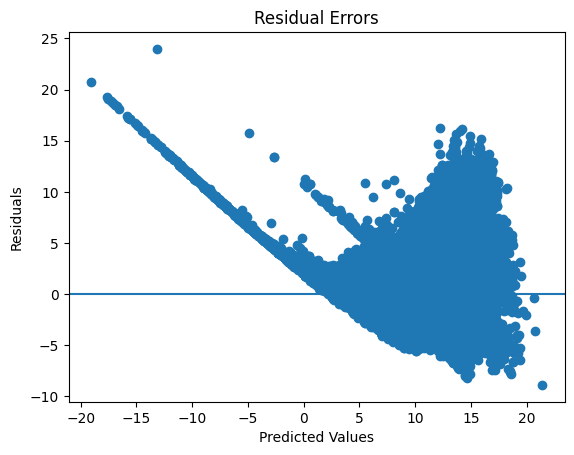

In [ ]:
# 📊 Visualization


# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Water Temperature")
plt.show()


# Residual Plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Errors")
plt.show()

In [ ]:
# 🚀 Optimization

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("\nRidge R2 Score:", r2_score(y_test, ridge_pred))


# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
print("Lasso R2 Score:", r2_score(y_test, lasso_pred))


Ridge R2 Score: 0.649279200458081
Lasso R2 Score: 0.6443065151401675
